In [1]:
import matplotlib.gridspec as gridspec
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import LogNorm


In [3]:
EJ = 3
EJ_over_EL_list = np.linspace(20,45,60)
EJ_over_EC_list = np.linspace(2,8,41)
X, Y = np.meshgrid(EJ_over_EC_list,EJ_over_EL_list)

import pickle
with open('data_v3_large_inductance.data', 'rb') as f:
    (EJ_over_EL_list, EJ_over_EC_list, EJ_over_EC_array, EJ_over_EL_array,
                 upside_down_phi_element01_array , upside_down_phi_element12_array ,
                   upside_down_freq01_array , upside_down_freq12_array ,
                     conventional_phi_element_array ,conventional_freq_array ,
                    upside_down_2nd_order_01_array ,upside_down_2nd_order_12_array ,conventional_2nd_order_array   ) = pickle.load(f)


hbar = 1/(2*np.pi)
def one_over_f_loss_rate(omega, EL, phi_element, one_over_f_flux_noise_amplitude):
    return_val = 8 * np.pi**3  # dimensionless
    return_val *= (EL / hbar)**2  # GHz^2
    return_val *= one_over_f_flux_noise_amplitude**2  # GHz^2
    return_val *= (phi_element)**2 / omega  # GHz
    return return_val

def dielectric_loss_rate(omega, EC, phi_element, Q_cap):
    temp_in_mK = 42  # K
    kB = 8.617333262e-5  # eV K−1
    beta = 1 / (kB * temp_in_mK * 1e-3)  # 1/eV

    return_val = hbar * omega**2  # h*GHZ^2
    return_val /= (4 * EC * Q_cap)  # GHZ
    return_val *= phi_element**2  # GHZ

    hbar_in_eVs = 6.5821e-16  # eV s
    coth_arg = beta * hbar_in_eVs * omega / 2  # s GHZ
    coth_arg *= 1e9  # dimensionless
    return_val *= 1 / np.tanh(coth_arg)  # GHZ
    return return_val

def T_phi(second_order_derivative, one_over_f_flux_noise_amplitude):  # eqn (13) of Peter Groszkowski et al 2018 New J. Phys. 20 043053
    omega_uv = 3 * 2 * np.pi  # GHz
    omega_ir = 1e-9 * 2 * np.pi  # GHz
    t = 10e3  # ns
    A = one_over_f_flux_noise_amplitude  # in unit of Phi0
    return_val = 2 * A**4 * second_order_derivative**2  # Phi0^4 GHZ^2 / Phi0^4
    return_val *= (np.log(omega_uv / omega_ir)**2 + 2 * np.log(omega_ir * t)**2)  # GHZ^2
    return_val = return_val**(-1/2)  # ns
    return return_val  # Seems the unit here should be millisecond? Where did miss a 1e3?

def compute_lifetimes(one_over_f_flux_noise_amplitude, Q_cap):
    conventional_dielectric_lifetime = np.zeros((len(EJ_over_EL_list), len(EJ_over_EC_list)))
    conventional_one_over_f_loss_lifetime = np.zeros((len(EJ_over_EL_list), len(EJ_over_EC_list)))
    conventional_dephasing_lifetime = np.zeros((len(EJ_over_EL_list), len(EJ_over_EC_list)))

    upside_down01_dielectric_lifetime = np.zeros((len(EJ_over_EL_list), len(EJ_over_EC_list)))
    upside_down01_one_over_f_loss_lifetime = np.zeros((len(EJ_over_EL_list), len(EJ_over_EC_list)))
    upside_down01_dephasing_lifetime = np.zeros((len(EJ_over_EL_list), len(EJ_over_EC_list)))

    upside_down12_dielectric_lifetime = np.zeros((len(EJ_over_EL_list), len(EJ_over_EC_list)))
    upside_down12_one_over_f_loss_lifetime = np.zeros((len(EJ_over_EL_list), len(EJ_over_EC_list)))
    upside_down12_dephasing_lifetime = np.zeros((len(EJ_over_EL_list), len(EJ_over_EC_list)))

    for i in range(len(EJ_over_EL_list)):
        for j in range(len(EJ_over_EC_list)):
            EC = EJ / EJ_over_EC_list[j]
            EL = EJ / EJ_over_EL_list[i]

            # Conventional lifetimes
            omega_conventional = conventional_freq_array[i, j] * 2 * np.pi
            phi_conventional = conventional_phi_element_array[i, j]
            second_order_conventional = conventional_2nd_order_array[i, j]

            conventional_dielectric_lifetime[i, j] = 1 / dielectric_loss_rate(omega_conventional, EC, phi_conventional, Q_cap)
            conventional_one_over_f_loss_lifetime[i, j] = 1 / one_over_f_loss_rate(omega_conventional, EL, phi_conventional, one_over_f_flux_noise_amplitude)
            conventional_dephasing_lifetime[i, j] = T_phi(second_order_conventional, one_over_f_flux_noise_amplitude)

            # Upside down 01 lifetimes
            omega_upside_down01 = upside_down_freq01_array[i, j] * 2 * np.pi
            phi_upside_down01 = upside_down_phi_element01_array[i, j]
            second_order_upside_down01 = upside_down_2nd_order_01_array[i, j]

            upside_down01_dielectric_lifetime[i, j] = 1 / dielectric_loss_rate(omega_upside_down01, EC, phi_upside_down01, Q_cap)
            upside_down01_one_over_f_loss_lifetime[i, j] = 1 / one_over_f_loss_rate(omega_upside_down01, EL, phi_upside_down01, one_over_f_flux_noise_amplitude)
            upside_down01_dephasing_lifetime[i, j] = T_phi(second_order_upside_down01, one_over_f_flux_noise_amplitude)

            # Upside down 12 lifetimes
            omega_upside_down12 = upside_down_freq12_array[i, j] * 2 * np.pi
            phi_upside_down12 = upside_down_phi_element12_array[i, j]
            second_order_upside_down12 = upside_down_2nd_order_12_array[i, j]

            upside_down12_dielectric_lifetime[i, j] = 1 / dielectric_loss_rate(omega_upside_down12, EC, phi_upside_down12, Q_cap)
            upside_down12_one_over_f_loss_lifetime[i, j] = 1 / one_over_f_loss_rate(omega_upside_down12, EL, phi_upside_down12, one_over_f_flux_noise_amplitude)
            upside_down12_dephasing_lifetime[i, j] = T_phi(second_order_upside_down12, one_over_f_flux_noise_amplitude)

    return {
        "conventional_dielectric_lifetime": conventional_dielectric_lifetime,
        "conventional_one_over_f_loss_lifetime": conventional_one_over_f_loss_lifetime,
        "conventional_dephasing_lifetime": conventional_dephasing_lifetime,
        "upside_down01_dielectric_lifetime": upside_down01_dielectric_lifetime,
        "upside_down01_one_over_f_loss_lifetime": upside_down01_one_over_f_loss_lifetime,
        "upside_down01_dephasing_lifetime": upside_down01_dephasing_lifetime,
        "upside_down12_dielectric_lifetime": upside_down12_dielectric_lifetime,
        "upside_down12_one_over_f_loss_lifetime": upside_down12_one_over_f_loss_lifetime,
        "upside_down12_dephasing_lifetime": upside_down12_dephasing_lifetime
    }

In [4]:
combinations = [[4e-6, 1e6],  # more 1/f, less dielectric loss 
                [2e-6, 5e5], 
                [1e-6, 2.5e5],
                [1e-6, 1e5]]

tot_results = { 
    "conventional": [],
    "upside_down01": [],
    "upside_down12": []
}
T1_results = { 
    "conventional": [],
    "upside_down01": [],
    "upside_down12": []
}
Tphi_results = { 
    "conventional": [],
    "upside_down01": [],
    "upside_down12": []
}

for amplitude, Q in combinations:
    lifetimes = compute_lifetimes(amplitude, Q)
    for catagory in ["conventional", "upside_down01", "upside_down12"]:
        dephasing_T = lifetimes[catagory+"_dephasing_lifetime"] / 1e6
        T1_tot = 2/(1/lifetimes[catagory+"_one_over_f_loss_lifetime"] + 1/lifetimes[catagory+"_dielectric_lifetime"])/1e6
        tot_results[catagory].append(1/(2/T1_tot + 1/dephasing_T))
        Tphi_results[catagory].append(dephasing_T)
        T1_results[catagory].append(T1_tot)


cmap = plt.get_cmap('gist_heat')
categories = ["conventional", "upside_down01", "upside_down12"]
titles = ["Conventional", "IFQ", "UIFQ"]
z_slices = [6, 3, 0, -3]
X, Y = np.meshgrid(EJ_over_EC_list[:31],EJ_over_EL_list)

EJ_over_EC_indices_for_big_T_tot = [6,12,18,21]
EJ_over_EC_indices_for_big_T1 = [10,16,23,27]
def plot_one_row(fig, results,norm,positions, type,title=False):
    for idx, category in enumerate(categories):
        ax = fig.add_axes(positions[idx], projection='3d',computed_zorder=False)
        if title:
            ax.set_title(titles[idx],y=0.95,size=14)
        for i, z_slice in enumerate(z_slices):
            data = results[category][i][:,:31]
            norm_data = norm(data)
            # c = ax.plot_surface(X, Y, data, levels=1000, zdir='z', offset=z_slice, cmap=cmap, norm=norm)
            z = np.full_like(X, z_slice)
            c = ax.plot_surface(X, Y, z, rstride=1, cstride=1, facecolors=plt.colormaps.get_cmap(cmap)(norm_data), shade=False,zorder=z_slice)
            
        for i, (z_slice,EJ_over_EC_idx) in enumerate(zip(z_slices,EJ_over_EC_indices_for_big_T_tot)):
            ax.scatter(EJ_over_EC_list[EJ_over_EC_idx], 30, z_slice, color='deepskyblue', s=50,zorder=z_slice+1)  
            ax.text(EJ_over_EC_list[EJ_over_EC_idx]+0.2, 29.5, z_slice, f"{data[-1][EJ_over_EC_idx]:.2f}",color='deepskyblue',zorder=z_slice+1.5,size=12)  
        # for i, (z_slice,EJ_over_EC_idx) in enumerate(zip(z_slices, EJ_over_EC_indices_for_big_T1)):
        #     ax.scatter(EJ_over_EC_list[EJ_over_EC_idx], 30, z_slice, color='green', s=50,zorder=z_slice+1)  
        #     ax.text(EJ_over_EC_list[EJ_over_EC_idx]+0.3, 30, z_slice, f"{data[-1][EJ_over_EC_idx]:.2f}",color='green',zorder=z_slice+1.5,size=12)  
            
        ax.set_xlabel('EJ/EC')
        ax.set_ylabel('EJ/EL')
        ax.set_zticks([])
        ax.set_zlim(min(z_slices) - 1, max(z_slices) + 1)
        ax.view_init(elev=15, azim=310)
        ax.invert_yaxis()
        # ax.set_xlim(3,6)


    cbar_ax = fig.add_axes(positions[3])
    cbar = fig.colorbar(matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap), ax=cbar_ax, shrink=2,orientation='vertical', pad=0.9, aspect=12,location='right',fraction=0.9,anchor=(-0.4,0.5))
    cbar_ax.axis('off')
    cbar.set_label(label=type,size=13)
    z_label_ax = fig.add_axes(positions[4])
    z_label_ax.text(0.6,0.7,rf'''$\eta = 4\mu\Phi_0$
    $Q_{{cap}}=1e6$''',ha='center',size=12)
    z_label_ax.text(0.6,0.56,rf'''$\eta = 2\mu\Phi_0$
    $Q_{{cap}}=5e5$''',ha='center',size=12)
    z_label_ax.text(0.6,0.4,rf'''$\eta = 1\mu\Phi_0$
    $Q_{{cap}}=2.5e5$''',ha='center',size=12)
    z_label_ax.text(0.6,0.26,rf'''$\eta = 1\mu\Phi_0$
    $Q_{{cap}}=1e5$''',ha='center',size=12)
    z_label_ax.axis('off')


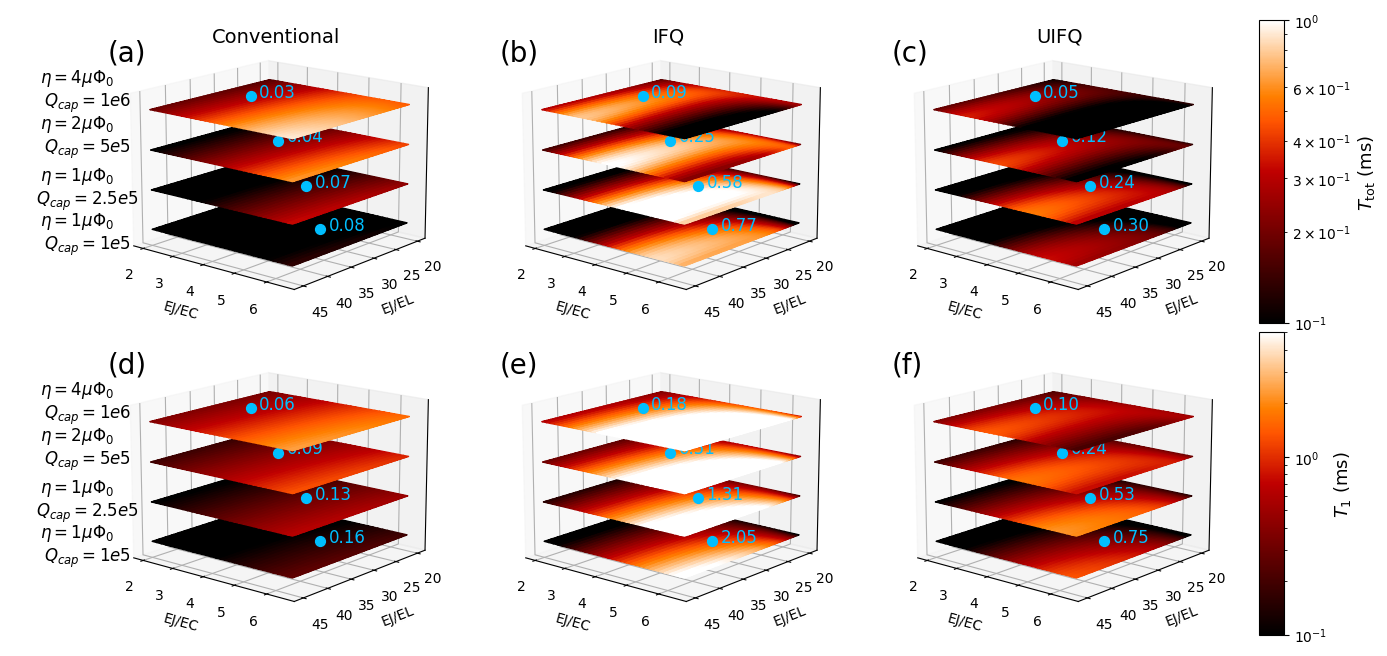

In [5]:

fig = plt.figure(figsize=(14, 6.5))

plot_one_row(fig, 
             results = tot_results,
             norm =  LogNorm(1e-1, 1),
             positions=[[0.05, 0.48, 0.28, 0.5],
                        [0.33, 0.48, 0.28, 0.5],
                        [0.61, 0.48, 0.28, 0.5],
                        [0.89, 0.48, 0.02, 0.5],
                        [0.0, 0.48, 0.08, 0.5]],
            type = rf'$T_\text{{tot}}$ (ms)',
            title=True)

plot_one_row(fig, 
             results = T1_results,
             norm =  LogNorm(1e-1, 5),
             positions=[[0.05, 0, 0.28, 0.5],
                        [0.33, 0, 0.28, 0.5],
                        [0.61, 0, 0.28, 0.5],
                        [0.89, 0, 0.02, 0.5],
                        [0.0, 0, 0.08, 0.5]],
            type = rf'$T_1$ (ms)',
            title=False)

fig.text(0.05+0.02, 0.9, '(a)', fontsize=20)
fig.text(0.33+0.02, 0.9, '(b)', fontsize=20)
fig.text(0.61+0.02, 0.9, '(c)', fontsize=20)

fig.text(0.05+0.02, 0.42, '(d)', fontsize=20)
fig.text(0.33+0.02, 0.42, '(e)', fontsize=20)
fig.text(0.61+0.02, 0.42, '(f)', fontsize=20)

plt.savefig('coherence_times.pdf')
plt.show()

In [6]:
combinations = [[4e-6, 1e6],  # more 1/f, less dielectric loss 
                [2e-6, 5e5], 
                [1e-6, 2.5e5],
                [1e-6, 1e5]]

tot_results = { 
    "conventional": [],
    "upside_down01": [],
    "upside_down12": []
}
T1_results = { 
    "conventional": [],
    "upside_down01": [],
    "upside_down12": []
}
Tphi_results = { 
    "conventional": [],
    "upside_down01": [],
    "upside_down12": []
}

for amplitude, Q in combinations:
    lifetimes = compute_lifetimes(amplitude, Q)
    for catagory in ["conventional", "upside_down01", "upside_down12"]:
        dephasing_T = lifetimes[catagory+"_dephasing_lifetime"] / 1e6
        T1_tot = 2/(1/lifetimes[catagory+"_one_over_f_loss_lifetime"] + 1/lifetimes[catagory+"_dielectric_lifetime"])/1e6
        tot_results[catagory].append(1/(2/T1_tot + 1/dephasing_T))
        Tphi_results[catagory].append(dephasing_T)
        T1_results[catagory].append(T1_tot)


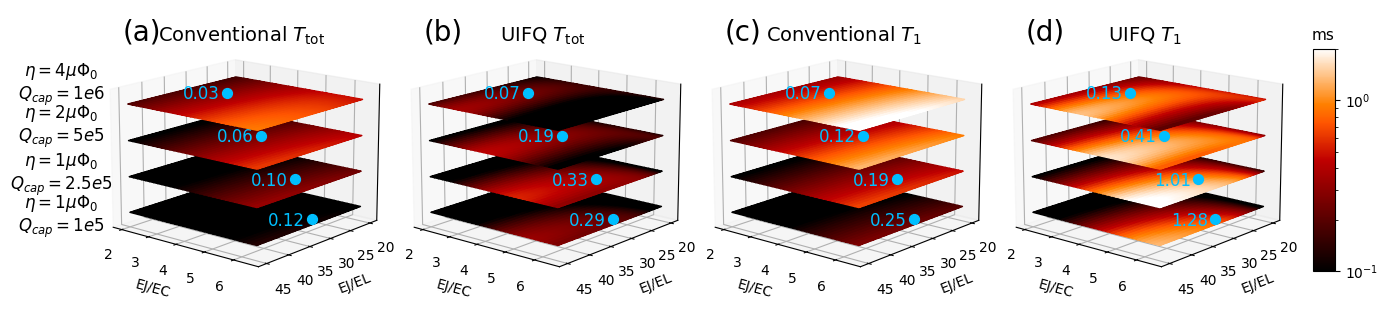

In [30]:


cmap = plt.get_cmap('gist_heat')
categories = ["conventional", "upside_down01", "upside_down12"]
titles = ["Conventional", "IFQ", "UIFQ"]
z_slices = [6, 3, 0, -3]
X, Y = np.meshgrid(EJ_over_EC_list[:31],EJ_over_EL_list)

fix_EJ_over_EL_for_big_T_tot = 30
EJ_over_EC_indices_for_big_T_tot = [8, 16, 24,28]


def plot_one_heatmap(fig, category,position,title, results,norm):
    ax = fig.add_axes(position, projection='3d',computed_zorder=False)
    if title:
        ax.set_title(title,y=0.95,size=14)
    
    # plot heatmaps for different combination of noises
    for i, z_slice in enumerate(z_slices):
        data = results[category][i][:,:31]
        norm_data = norm(data)
        z = np.full_like(X, z_slice)
        c = ax.plot_surface(X, Y, z, rstride=1, cstride=1, facecolors=plt.colormaps.get_cmap(cmap)(norm_data), shade=False,zorder=z_slice)
    
    # for each combination of noises do a data point labelling
    for i, (z_slice,EJ_over_EC_idx) in enumerate(zip(z_slices,EJ_over_EC_indices_for_big_T_tot)):
        ax.scatter(EJ_over_EC_list[EJ_over_EC_idx], fix_EJ_over_EL_for_big_T_tot, z_slice, color='deepskyblue', s=50,zorder=z_slice+1)  
        ax.text(EJ_over_EC_list[EJ_over_EC_idx]-0.5, fix_EJ_over_EL_for_big_T_tot+7, z_slice, f"{data[-1][EJ_over_EC_idx]:.2f}",color='deepskyblue',zorder=z_slice+1.5,size=12)  
        
    ax.set_xlabel('EJ/EC')
    ax.set_ylabel('EJ/EL')
    ax.set_zticks([])
    ax.set_zlim(min(z_slices) - 1, max(z_slices) + 1)
    ax.view_init(elev=15, azim=310)
    ax.invert_yaxis()
    # ax.set_xlim(3,6)

norm =  LogNorm(1e-1, 2)
fig = plt.figure(figsize=(14, 3.0))

labels_width = 0.06
heatmap_width = 0.21
heatmap_wspace = 0.005

positions = [[labels_width, 0, heatmap_width, 1], 
            [labels_width + 1* (heatmap_width + heatmap_wspace), 0, heatmap_width, 1],
            [labels_width + 2* (heatmap_width + heatmap_wspace), 0, heatmap_width, 1],
            [labels_width + 3* (heatmap_width + heatmap_wspace), 0, heatmap_width, 1],
            [0.0, 0, labels_width, 1], # z_label
            [labels_width + 4* (heatmap_width + heatmap_wspace) - 0.027, 0, - 0.027 + 1-(labels_width + 4* (heatmap_width + heatmap_wspace)) ,1]]
plot_one_heatmap(fig, 
                 category = "conventional",
                 position = positions[0],
                 title = rf'Conventional $T_\text{{tot}}$', 
                 results = tot_results,
                 norm = norm)
plot_one_heatmap(fig, 
                 category = "upside_down12",
                 position = positions[1],
                 title = rf'UIFQ $T_\text{{tot}}$', 
                 results = tot_results,
                 norm = norm)

plot_one_heatmap(fig, 
                 category = "conventional",
                 position = positions[2],
                 title = rf'Conventional $T_1$', 
                 results = T1_results,
                 norm = norm)
plot_one_heatmap(fig, 
                 category = "upside_down12",
                 position = positions[3],
                 title = rf'UIFQ $T_1$', 
                 results = T1_results,
                 norm = norm)


fig.text(labels_width+0.02, 0.9, '(a)', fontsize=20)
fig.text(labels_width + 1* (heatmap_width + heatmap_wspace)+0.02, 0.9, '(b)', fontsize=20)
fig.text(labels_width + 2* (heatmap_width + heatmap_wspace)+0.02, 0.9, '(c)', fontsize=20)
fig.text(labels_width + 3* (heatmap_width + heatmap_wspace)+0.02, 0.9, '(d)', fontsize=20)

cbar_ax = fig.add_axes(positions[5])
cbar = fig.colorbar(matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap), ax=cbar_ax, shrink=3,orientation='vertical', pad=0.0, aspect=10,location='right',fraction=0.3,anchor=(-1,0.5))
cbar_ax.axis('off')
cbar_ax.text(1.2,0.9,rf'ms',ha='center',size=11)
# cbar.set_label(label="ms",size=13,loc='top')

z_label_ax = fig.add_axes(positions[4])
z_label_ax.text(0.6,0.7,rf'''$\eta = 4\mu\Phi_0$
$Q_{{cap}}=1e6$''',ha='center',size=12)
z_label_ax.text(0.6,0.56,rf'''$\eta = 2\mu\Phi_0$
$Q_{{cap}}=5e5$''',ha='center',size=12)
z_label_ax.text(0.6,0.4,rf'''$\eta = 1\mu\Phi_0$
$Q_{{cap}}=2.5e5$''',ha='center',size=12)
z_label_ax.text(0.6,0.26,rf'''$\eta = 1\mu\Phi_0$
$Q_{{cap}}=1e5$''',ha='center',size=12)
z_label_ax.axis('off')

plt.savefig('fig02_coherence_heatmap_conventional_and_UIFQ.pdf')
plt.show()

In [22]:
EJ_over_EC_list[31]

6.6499999999999995

# 